### EuroSAT
- 텐서플로 데이터셋
- 인공위성에서 지표면을 촬영한 이미지와 토지이용분류 값이 정리 되어있는 데이터셋
- EU의 코페르니쿠스 지구 관측 프로그램에 의해 제공되는 공용 데이터셋인 Sentinel-2위성이 관측한 이미지를 기반
- 총 27,000장의 위성 사진과 10개의 토지이용분류 값이 매칭되어 제공

  
#### 숫자 클래스 이름 (문자열)
- 0 AnnualCrop : 일년생 작물 (매년 새로 심는 농작물 밭. 밀, 옥수수, 콩 등. 계절마다 색이 바뀜)
- 1 Forest : 숲 (나무가 빽빽하게 우거진 산림 지역)
- 2 HerbaceousVegetation : 초본 식생 (나무 없이 풀, 잡초, 야생화로 덮인 땅)
- 3 Highway : 고속도로
- 4 Industrial : 공업 지역 (공장, 창고, 물류센터 등. 큰 건물과 주차장이 많음)
- 5 Pasture : 목초지소 (양 등 가축을 키우는 풀밭. 작물 없이 균일한 초록색)
- 6 PermanentCrop : 다년생 작물 (한번 심으면 여러 해 수확하는 작물. 포도밭, 과수원 등)
- 7 Residential : 주거 지역 (아파트, 주택가 등. 건물 + 도로 + 나무가 섞인 패턴)
- 8 River : 강(구불구불한 물줄기. 주변 식생과 색이 다름)
- 9 SeaLake :바다/호수(넓고 균일한 수면. 강보다 훨씬 넓은 물 영역)

In [1]:
import os
import pathlib
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator as imgen
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten , Dropout,BatchNormalization , GlobalAveragePooling2D

In [2]:
data_dir = 'dataset/2750'
img_size = (64,64)
batch_size = 64
num_classes = 10

In [3]:
# 학습용 데이터 : 데이터 증강 , 정규화
train_gen_aug = imgen(rescale=1/255. ,horizontal_flip = True,
                 vertical_flip = True,
                 rotation_range=90, zoom_range = 0.2,
                 width_shift_range=0.1,
                 height_shift_range=0.1,
                 brightness_range=[0.7,1.3],
                 validation_split = 0.2) # 전체 중 20%를 검증용으로 분

# 검증용 데이터 : 정규화
valid_gen = imgen(rescale=1/255. , validation_split=0.2)

In [4]:
train_data_aug = train_gen_aug.flow_from_directory(
    data_dir, 
    batch_size = batch_size , 
    target_size = img_size , 
    class_mode = 'sparse',      # 정수 레이블 (200개 클래스)
    subset = 'training' ,       # 학습용(80%)
    seed = 123
)

valid_data = valid_gen.flow_from_directory(
    data_dir, 
    batch_size = batch_size , 
    target_size = img_size , 
    class_mode = 'sparse',      # 정수 레이블 (200개 클래스)
    subset = 'validation' ,       # 학습용(80%)
    seed = 123
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


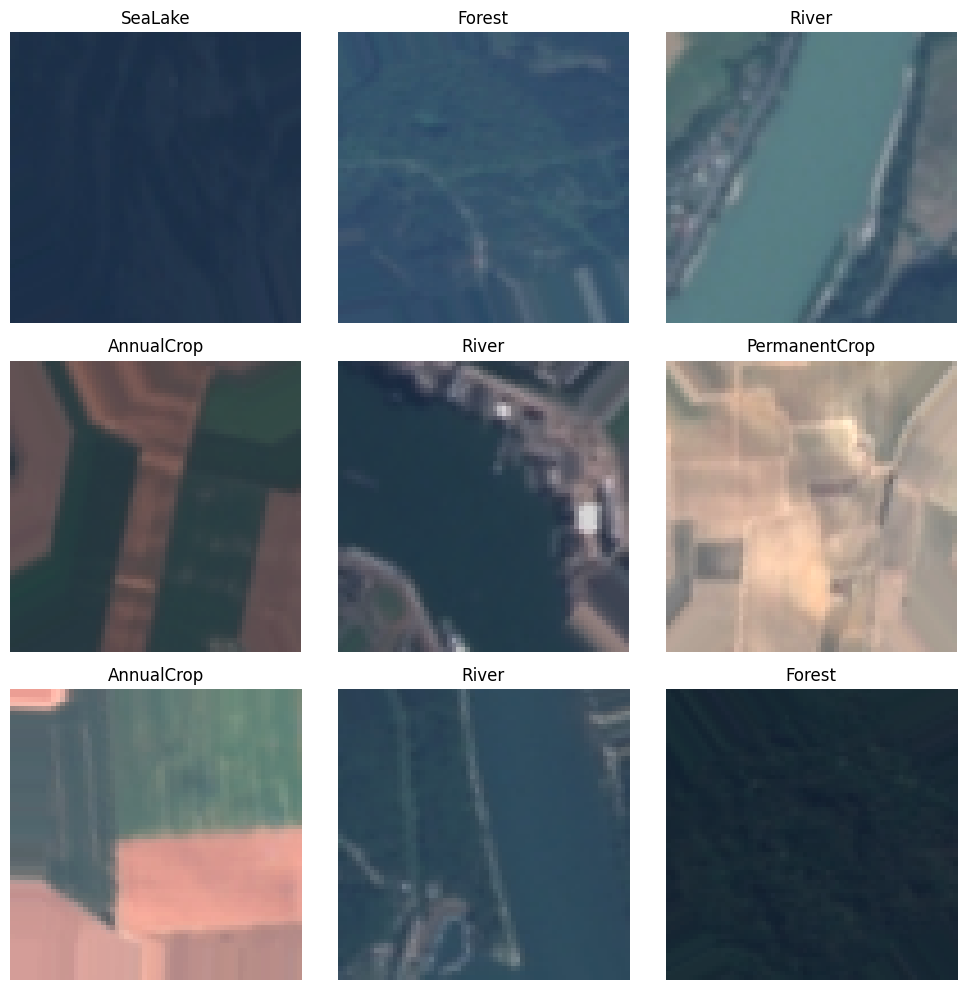

In [5]:
# 샘플이미지

images , labels = next(train_data_aug)
class_name = list(train_data_aug.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_name[int(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
model_01 = Sequential()

model_01.add(Conv2D(32,3,padding='same',activation='relu',input_shape=(64,64,3)))
model_01.add(MaxPooling2D(2,2))
model_01.add(BatchNormalization())

model_01.add(Conv2D(64,3,padding='same',activation='relu'))
model_01.add(MaxPooling2D(2,2))
model_01.add(BatchNormalization())

model_01.add(Conv2D(128,3,padding='same',activation='relu'))
model_01.add(MaxPooling2D(2,2))
model_01.add(BatchNormalization())

# model.add(Flatten())
model_01.add(GlobalAveragePooling2D())
model_01.add(Dense(256,activation='relu'))
model_01.add(Dropout(0.3))
model_01.add(Dense(128,activation='relu'))
model_01.add(Dropout(0.3))
model_01.add(Dense(num_classes , activation='softmax'))

model_01.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                        

In [7]:
model_01.compile(optimizer='adam' , loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [8]:
callback_01 = [EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1)]

In [9]:
history = model_01.fit(train_data_aug, validation_data = valid_data, 
                   epochs=50 , callbacks = callback_01)

Epoch 1/50
338/338 [==============================] - 47s 128ms/step - loss: 1.1905 - accuracy: 0.5689 - val_loss: 3.3843 - val_accuracy: 0.2793
Epoch 2/50
338/338 [==============================] - 36s 107ms/step - loss: 0.8459 - accuracy: 0.6966 - val_loss: 1.2414 - val_accuracy: 0.5726
Epoch 3/50
338/338 [==============================] - 36s 108ms/step - loss: 0.7434 - accuracy: 0.7377 - val_loss: 0.9196 - val_accuracy: 0.6694
Epoch 4/50
338/338 [==============================] - 44s 129ms/step - loss: 0.6639 - accuracy: 0.7662 - val_loss: 0.7859 - val_accuracy: 0.7454
Epoch 5/50
338/338 [==============================] - 45s 134ms/step - loss: 0.5867 - accuracy: 0.7955 - val_loss: 0.7663 - val_accuracy: 0.7639
Epoch 6/50
338/338 [==============================] - 36s 107ms/step - loss: 0.5327 - accuracy: 0.8188 - val_loss: 0.4595 - val_accuracy: 0.8383
Epoch 7/50
338/338 [==============================] - 43s 126ms/step - loss: 0.4907 - accuracy: 0.8306 - val_loss: 1.1396 - val_ac

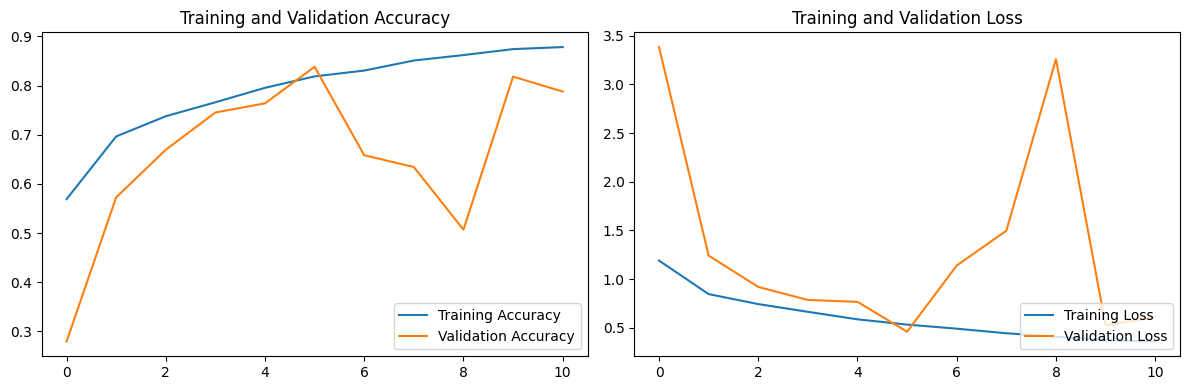

In [10]:
acc_01 = history.history['accuracy']
val_acc_01 = history.history['val_accuracy']
loss_01 = history.history['loss']
val_loss_01 = history.history['val_loss']

epochs_range_01 = np.arange(len(val_loss_01))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range_01 , acc_01 , label = 'Training Accuracy')
plt.plot(epochs_range_01 , val_acc_01 , label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range_01 , loss_01 , label = 'Training Loss')
plt.plot(epochs_range_01 , val_loss_01 , label = 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

### 전이 학습

- ResNet50V2 : 마이크로소프트 연구팀에서 2015년에 발표한 모델

In [11]:
train_data_aug.reset()
valid_data.reset()

In [13]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# 모델 만들기
base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)

base_model.trainable = False  # 사전 학습 가중치 유지 (feature extractor로 사용)

model_02 = Sequential()
model_02.add(base_model)

model_02.add(GlobalAveragePooling2D())
model_02.add(Dense(256, activation='relu'))
model_02.add(Dropout(0.3))
model_02.add(Dense(128, activation='relu'))
model_02.add(Dropout(0.3))
model_02.add(Dense(num_classes, activation='softmax'))

model_02.summary()

94668760/94668760 [==============================] - 4s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 2, 2, 2048)        23564800  
                                                                 
 global_average_pooling2d_1   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_3 (Dense)             (None, 256)               524544    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dropout_3 (Dropout)         (None, 128)               

In [21]:
callback_02 = [EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1)]

In [23]:
model_02.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ← 이걸로
    metrics=['accuracy']
)

history = model_02.fit(
    train_data_aug,
    validation_data=valid_data,
    epochs=50,
    callbacks=callback_02
)

Epoch 1/50
338/338 [==============================] - 40s 110ms/step - loss: 0.9799 - accuracy: 0.6780 - val_loss: 0.6009 - val_accuracy: 0.8009
Epoch 2/50
338/338 [==============================] - 33s 98ms/step - loss: 0.7223 - accuracy: 0.7610 - val_loss: 0.5229 - val_accuracy: 0.8270
Epoch 3/50
338/338 [==============================] - 33s 97ms/step - loss: 0.6698 - accuracy: 0.7762 - val_loss: 0.5200 - val_accuracy: 0.8265
Epoch 4/50
338/338 [==============================] - 33s 98ms/step - loss: 0.6429 - accuracy: 0.7844 - val_loss: 0.5172 - val_accuracy: 0.8204
Epoch 5/50
338/338 [==============================] - 41s 122ms/step - loss: 0.6367 - accuracy: 0.7873 - val_loss: 0.4948 - val_accuracy: 0.8287
Epoch 6/50
338/338 [==============================] - 39s 115ms/step - loss: 0.6232 - accuracy: 0.7889 - val_loss: 0.4843 - val_accuracy: 0.8380
Epoch 7/50
338/338 [==============================] - 34s 101ms/step - loss: 0.6066 - accuracy: 0.7959 - val_loss: 0.4811 - val_accur